## Review와 Sales 히스토그램

#### * 잘 팔리는 놈들 5개 못 팔리는 놈들 5개 히스토그램 비교

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Data Load

In [49]:
df = pd.read_csv("review-vc_sales-by_collection_category_20250430.csv")

In [57]:
data = df[df['collection'] == '__TOTAL__'].copy()
#df2 = df1[['yr_month','financial_category','written_avg_rating','sales_amount']]

In [59]:
#df2[df2['financial_category'] == 'Box Springs']
data

,yr_month,financial_category,collection,coalesce_collection,mapped_bigbox_collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,__TOTAL__,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
31,202201,Foam Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,3.314070,157.0,398.0,0.394472,NaN,NaN,NaN,NaN,9613915.51,31078.0
74,202201,Non Bedroom Furniture,__TOTAL__,__TOTAL__,__TOTAL__,3.853333,19.0,75.0,0.253333,NaN,NaN,NaN,NaN,518281.03,4766.0
122,202201,Other Frames & Beds,__TOTAL__,__TOTAL__,__TOTAL__,4.151079,27.0,139.0,0.194245,NaN,NaN,NaN,NaN,1031690.10,11887.0
151,202201,Others,__TOTAL__,__TOTAL__,__TOTAL__,4.550000,5.0,80.0,0.062500,NaN,NaN,NaN,NaN,275074.99,6457.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23525,202504,Platform Beds,__TOTAL__,__TOTAL__,__TOTAL__,3.568182,42.0,132.0,0.318182,3.568182,42.0,132.0,0.318182,2997728.24,25295.0
23645,202504,SmartBases,__TOTAL__,__TOTAL__,__TOTAL__,3.100000,13.0,30.0,0.433333,3.100000,13.0,30.0,0.433333,437267.21,5978.0
23657,202504,Sofa,__TOTAL__,__TOTAL__,__TOTAL__,5.000000,0.0,2.0,0.000000,5.000000,0.0,2.0,0.000000,82369.67,679.0
23668,202504,Spring Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,2.988095,40.0,84.0,0.476190,2.988095,40.0,84.0,0.476190,3296833.06,19120.0


In [61]:
data['yr_month'] = pd.to_datetime(data['yr_month'], format='%Y%m')

In [63]:
mattress_categories = ["Foam Mattresses","Spring Mattresses"]
data["category_type"] = data["financial_category"].apply(lambda x: "Mattress" if x in mattress_categories else "Non-Mattress")

In [65]:
data

,yr_month,financial_category,collection,coalesce_collection,mapped_bigbox_collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type
0,2022-01-01,Box Springs,__TOTAL__,__TOTAL__,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0,Non-Mattress
31,2022-01-01,Foam Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,3.314070,157.0,398.0,0.394472,NaN,NaN,NaN,NaN,9613915.51,31078.0,Mattress
74,2022-01-01,Non Bedroom Furniture,__TOTAL__,__TOTAL__,__TOTAL__,3.853333,19.0,75.0,0.253333,NaN,NaN,NaN,NaN,518281.03,4766.0,Non-Mattress
122,2022-01-01,Other Frames & Beds,__TOTAL__,__TOTAL__,__TOTAL__,4.151079,27.0,139.0,0.194245,NaN,NaN,NaN,NaN,1031690.10,11887.0,Non-Mattress
151,2022-01-01,Others,__TOTAL__,__TOTAL__,__TOTAL__,4.550000,5.0,80.0,0.062500,NaN,NaN,NaN,NaN,275074.99,6457.0,Non-Mattress
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23525,2025-04-01,Platform Beds,__TOTAL__,__TOTAL__,__TOTAL__,3.568182,42.0,132.0,0.318182,3.568182,42.0,132.0,0.318182,2997728.24,25295.0,Non-Mattress
23645,2025-04-01,SmartBases,__TOTAL__,__TOTAL__,__TOTAL__,3.100000,13.0,30.0,0.433333,3.100000,13.0,30.0,0.433333,437267.21,5978.0,Non-Mattress
23657,2025-04-01,Sofa,__TOTAL__,__TOTAL__,__TOTAL__,5.000000,0.0,2.0,0.000000,5.000000,0.0,2.0,0.000000,82369.67,679.0,Non-Mattress
23668,2025-04-01,Spring Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,2.988095,40.0,84.0,0.476190,2.988095,40.0,84.0,0.476190,3296833.06,19120.0,Mattress


## 상관계수 히트맵

In [70]:
# 수치형 컬럼만 선택
#numeric_cols = ['all_avg_rating', 'all_all_cnt', 'written_12_ratio', 'sales_amount']
#numeric_cols = ['written_avg_rating', 'written_12_cnt', 'written_all_cnt', 'written_12_ratio', 'sales_amount']
numeric_cols = ['written_avg_rating', 'witten_all_cnt', 'sales_amount']
corr = data[numeric_cols].corr()


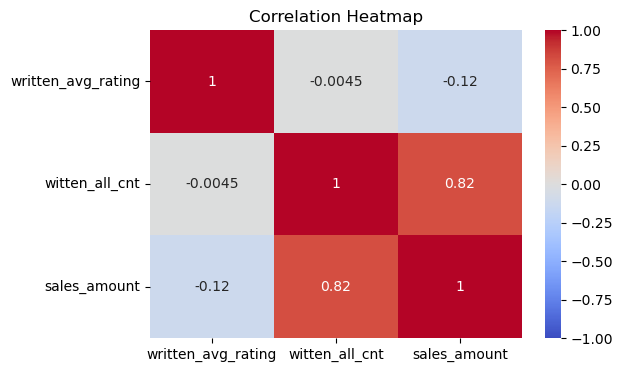

In [72]:

# 히트맵 생성
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

## 평점과 판매액 간의 시계열 

In [74]:
monthly_sales_by_category = data.groupby(['yr_month', 'category_type']).agg({'sales_amount': 'sum', 'written_avg_rating':'mean'}).reset_index()

In [76]:
mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Mattress"]
non_mattress_data = monthly_sales_by_category[monthly_sales_by_category["category_type"] == "Non-Mattress"]

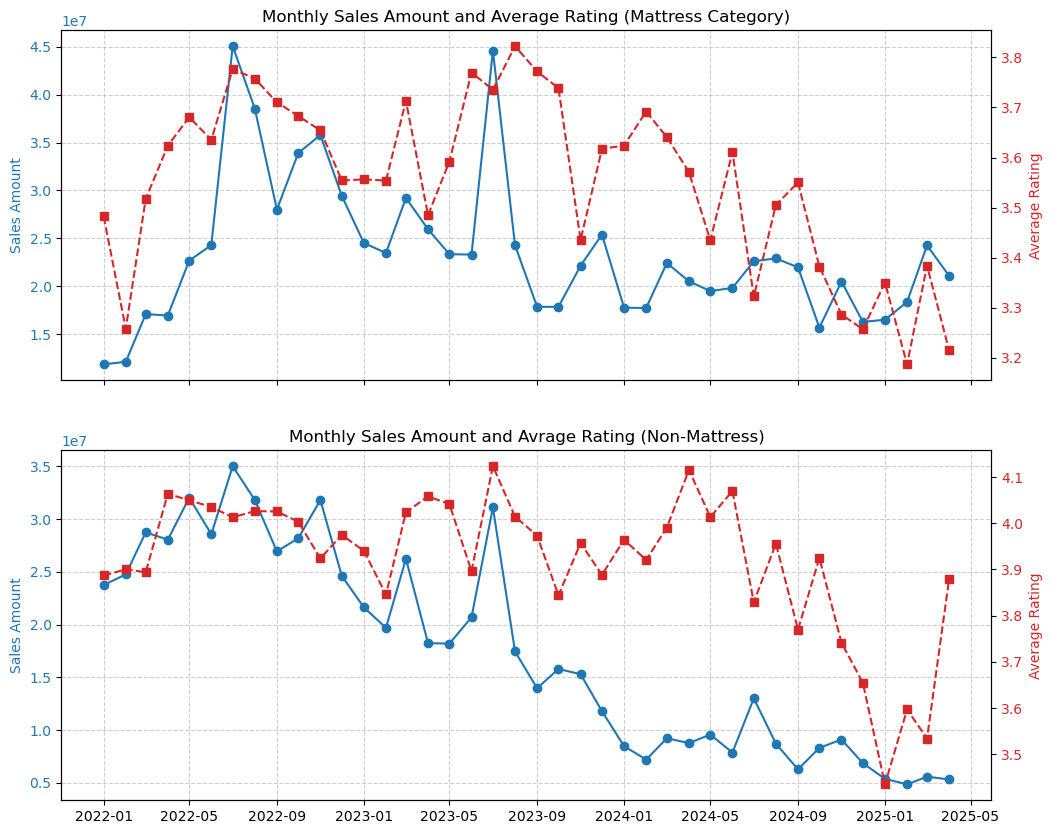

In [78]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,10), sharex=True)

ax1.set_title("Monthly Sales Amount and Average Rating (Mattress Category)") 
#ax1.set_xlabel("Month")
ax1.set_ylabel("Sales Amount", color='tab:blue')
ax1.plot(mattress_data['yr_month'], mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, linestyle='--', alpha=0.6)

ax3 = ax1.twinx()
ax3.set_ylabel("Average Rating", color='tab:red')
ax3.plot(mattress_data['yr_month'], mattress_data['written_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax3.tick_params(axis='y', labelcolor='tab:red')

ax2.set_title("Monthly Sales Amount and Avrage Rating (Non-Mattress)")
ax2.set_ylabel("Sales Amount", color='tab:blue')
ax2.plot(non_mattress_data['yr_month'], non_mattress_data['sales_amount'], marker='o', color='tab:blue', label="Sales Amount")
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax2.grid(True, linestyle='--', alpha=0.6)

ax4 = ax2.twinx()
ax4.set_ylabel("Average Rating", color='tab:red')
ax4.plot(non_mattress_data['yr_month'], non_mattress_data['written_avg_rating'], marker='s', color='tab:red', linestyle='dashed', label="Average Rating")
ax4.tick_params(axis='y', labelcolor='tab:red')

plt.show()


In [80]:
#non_mattress_data['written_avg_rating'].max()
non_mattress_data['written_avg_rating'].min()

3.434789467375

## 평점 수준별 매출 히스토그램

In [83]:
bins = [i/10 for i in range(int(data['written_avg_rating'].min()*10), int(data['written_avg_rating'].max() * 10) + 2)]

In [85]:
data['rating_bin'] = pd.cut(data['written_avg_rating'], bins=bins, right=False)

In [87]:
data[data['category_type']=="Mattress"]['sales_amount'].sum()

935488899.0

In [89]:
rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_18912\1249324559.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales = data.groupby(["rating_bin", "category_type"])["sales_amount"].sum().unstack().fillna(0) / 1000000


In [91]:
rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000

C:\Users\최태욱\AppData\Local\Temp\ipykernel_18912\3906643850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_by_category = data.groupby(['rating_bin','financial_category'])['sales_amount'].sum().unstack().fillna(0)/1000000


In [93]:
rating_sales_by_category

financial_category,Box Springs,Foam Mattresses,Non Bedroom Furniture,Other Frames & Beds,Others,Platform Beds,SmartBases,Sofa,Spring Mattresses,Toppers
rating_bin,,,,,,,,,,
"[2.0, 2.1)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.110085
"[2.1, 2.2)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[2.2, 2.3)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.412770
"[2.3, 2.4)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
"[2.4, 2.5)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.131901,0.000000,1.456108
"[2.5, 2.6)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.510267
"[2.6, 2.7)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.116455,0.000000,0.941009
"[2.7, 2.8)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.959049
"[2.8, 2.9)",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.199699,0.000000,0.157215


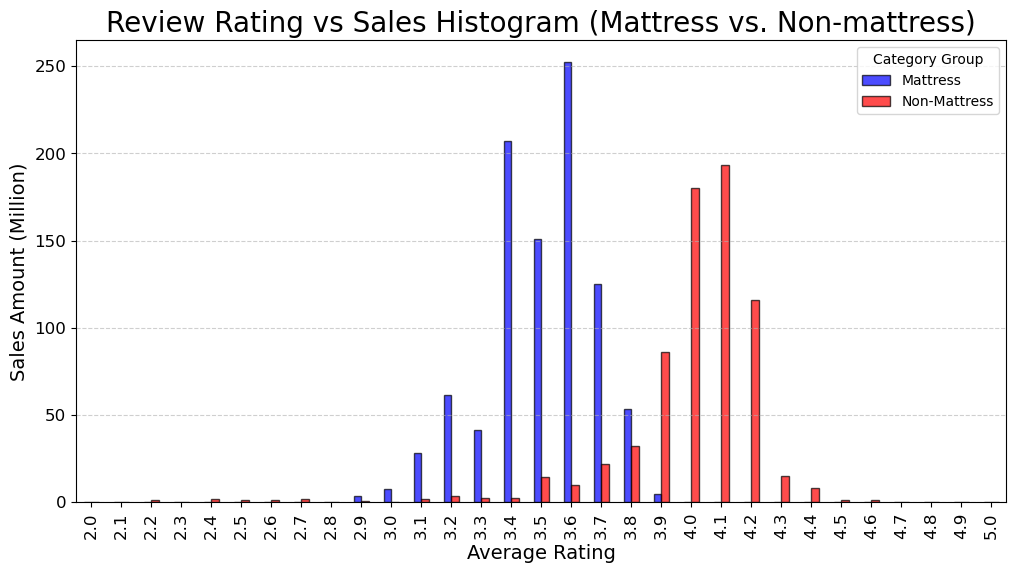

In [126]:
fig, ax = plt.subplots(figsize=(12,6))
rating_sales.plot(kind='bar', stacked=False, color=['blue','red'], edgecolor='black', alpha=0.7, ax=ax)

x_labels = [round(b.left, 1) for b in rating_sales.index]
ax.set_xticklabels(x_labels, rotation=90, fontsize=12)
ax.tick_params(axis='y', labelsize=12)  # y축 눈금 크기

plt.xlabel("Average Rating", fontsize=14)
plt.ylabel("Sales Amount (Million)", fontsize=14)
plt.title("Review Rating vs Sales Histogram (Mattress vs. Non-mattress)", fontsize=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Category Group", labels=["Mattress", "Non-Mattress"])

plt.show()

## Category별 히스토그램 

In [98]:
data

,yr_month,financial_category,collection,coalesce_collection,mapped_bigbox_collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty,category_type,rating_bin
0,2022-01-01,Box Springs,__TOTAL__,__TOTAL__,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0,Non-Mattress,"[4.1, 4.2)"
31,2022-01-01,Foam Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,3.314070,157.0,398.0,0.394472,NaN,NaN,NaN,NaN,9613915.51,31078.0,Mattress,"[3.3, 3.4)"
74,2022-01-01,Non Bedroom Furniture,__TOTAL__,__TOTAL__,__TOTAL__,3.853333,19.0,75.0,0.253333,NaN,NaN,NaN,NaN,518281.03,4766.0,Non-Mattress,"[3.8, 3.9)"
122,2022-01-01,Other Frames & Beds,__TOTAL__,__TOTAL__,__TOTAL__,4.151079,27.0,139.0,0.194245,NaN,NaN,NaN,NaN,1031690.10,11887.0,Non-Mattress,"[4.1, 4.2)"
151,2022-01-01,Others,__TOTAL__,__TOTAL__,__TOTAL__,4.550000,5.0,80.0,0.062500,NaN,NaN,NaN,NaN,275074.99,6457.0,Non-Mattress,"[4.5, 4.6)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23525,2025-04-01,Platform Beds,__TOTAL__,__TOTAL__,__TOTAL__,3.568182,42.0,132.0,0.318182,3.568182,42.0,132.0,0.318182,2997728.24,25295.0,Non-Mattress,"[3.5, 3.6)"
23645,2025-04-01,SmartBases,__TOTAL__,__TOTAL__,__TOTAL__,3.100000,13.0,30.0,0.433333,3.100000,13.0,30.0,0.433333,437267.21,5978.0,Non-Mattress,"[3.1, 3.2)"
23657,2025-04-01,Sofa,__TOTAL__,__TOTAL__,__TOTAL__,5.000000,0.0,2.0,0.000000,5.000000,0.0,2.0,0.000000,82369.67,679.0,Non-Mattress,"[5.0, 5.1)"
23668,2025-04-01,Spring Mattresses,__TOTAL__,__TOTAL__,__TOTAL__,2.988095,40.0,84.0,0.476190,2.988095,40.0,84.0,0.476190,3296833.06,19120.0,Mattress,"[2.9, 3.0)"


In [100]:
categories = data['financial_category'].unique()
num_categories = len(categories)

In [102]:
bins1 = [round(x * 0.1, 1) for x in range(int(data['written_avg_rating'].min()*10)-1, int(data['written_avg_rating'].max()*10)+2)]
#subset['rating_bin']=data.cut(subset['written_avg_rating'], bins=bins1)

C:\Users\최태욱\AppData\Local\Temp\ipykernel_18912\3440972288.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_18912\3440972288.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000
C:\Users\최태욱\AppData\Local\Temp\ipykernel_18912\3440972288.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain

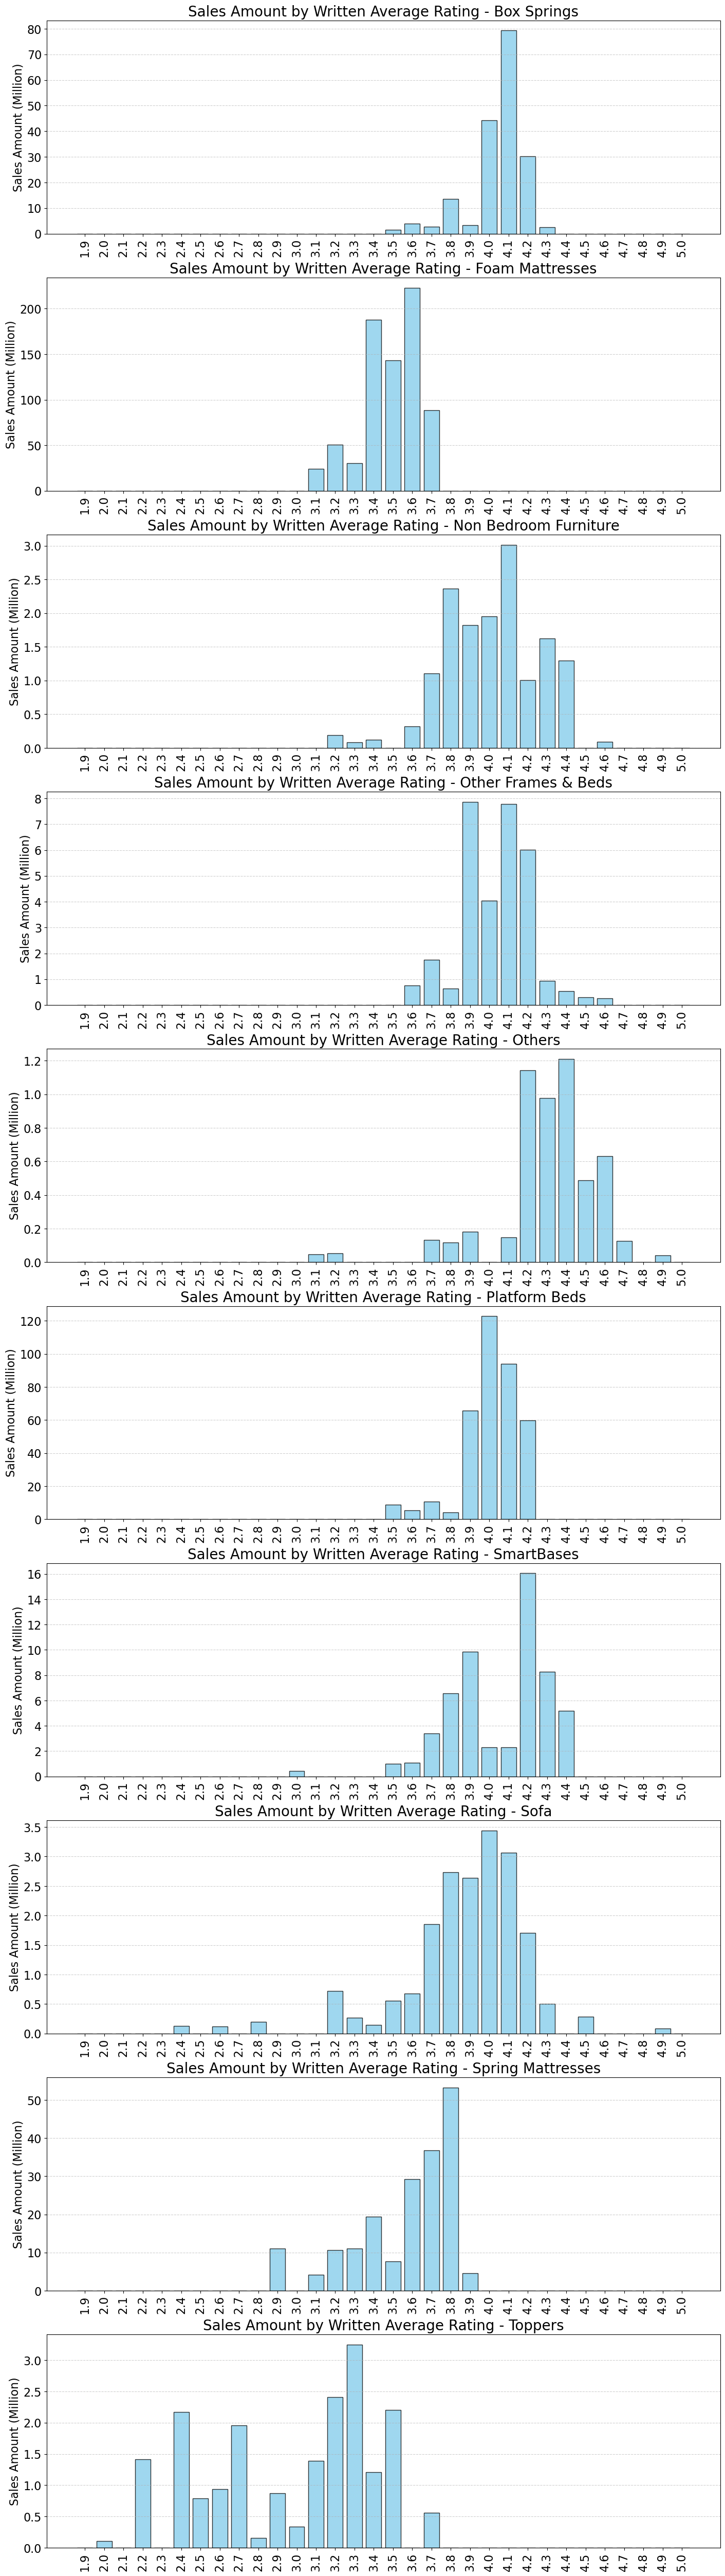

In [116]:
fig, axes = plt.subplots(num_categories, 1, figsize=(14,5*num_categories), constrained_layout=True)

for i, category in enumerate(categories):
    subset = data[data['financial_category']==category].copy()
    subset['rating_bin1'] = pd.cut(subset['written_avg_rating'], bins=bins1)
    rating_sales_sum = subset.groupby('rating_bin1')['sales_amount'].sum().fillna(0) / 1000000

    x_labels = [round(interval.left,1) for interval in rating_sales_sum.index]
    
    axes[i].bar(range(len(x_labels)), rating_sales_sum.values, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Sales Amount by Written Average Rating - {category}', fontsize=20)
    #axes[i].set_xlabel('Written Average Rating (0.1 intervals)', fontsize=12)
    axes[i].set_ylabel('Sales Amount (Million)', fontsize=16)
    axes[i].set_xticks(range(len(x_labels)))
    axes[i].set_xticklabels(x_labels, rotation=90, fontsize=16)
    axes[i].tick_params(axis='y', labelsize=16)  # y축 글자 크기 조절
    #axes[i].set_ylim(0, 300)  # Y축 범위 고정
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.show()